# 💳 Transaction Risk Analysis & ML Pipeline
## Notebook 3 — Model Training: XGBoost vs Logistic Regression + MLflow


In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, confusion_matrix
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('transactions_features.csv')
print(f'✅ Loaded: {df.shape}')

✅ Loaded: (1852394, 25)


## Step 1 — Prepare Features

In [2]:
# Encode categoricals
le = LabelEncoder()
df['category_enc'] = le.fit_transform(df['category'].astype(str))
df['state_enc']    = le.fit_transform(df['state'].astype(str))

feature_cols = [
    'amt', 'hour', 'day_of_week', 'month', 'age',
    'category_enc', 'state_enc',
    'amt_vs_customer_avg', 'customer_txn_count',
    'unique_categories', 'unique_states',
    'is_late_night', 'is_weekend', 'is_high_value',
    'customer_late_night_ratio', 'near_customer_max',
    'is_high_risk_category', 'is_senior', 'is_young',
    'customer_max_amount', 'customer_avg_amount', 'is_multi_state'
]

X = df[feature_cols].fillna(0)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'✅ Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'   Features: {len(feature_cols)}')
print(f'   Fraud rate: {y.mean()*100:.2f}%')

✅ Train: 1,481,915 | Test: 370,479
   Features: 22
   Fraud rate: 0.52%


## Step 2 — Train Models with MLflow Tracking

In [3]:
mlflow.set_experiment('transaction_risk_analysis')
results = {}

# --- Logistic Regression ---
with mlflow.start_run(run_name='logistic_regression'):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    lr.fit(X_train_s, y_train)
    lr_probs = lr.predict_proba(X_test_s)[:,1]
    lr_auc   = roc_auc_score(y_test, lr_probs)

    mlflow.log_param('model', 'LogisticRegression')
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_metric('roc_auc', lr_auc)
    mlflow.sklearn.log_model(lr, 'model')
    results['Logistic Regression'] = {'auc': lr_auc, 'probs': lr_probs}
    print(f'✅ Logistic Regression  ROC-AUC: {lr_auc:.4f}')

# --- XGBoost ---
with mlflow.start_run(run_name='xgboost'):
    scale_pos = (y_train==0).sum() / (y_train==1).sum()
    xgb = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos, random_state=42,
        eval_metric='logloss', verbosity=0
    )
    xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    xgb_probs = xgb.predict_proba(X_test)[:,1]
    xgb_auc   = roc_auc_score(y_test, xgb_probs)

    mlflow.log_param('model', 'XGBoost')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('max_depth', 6)
    mlflow.log_param('learning_rate', 0.1)
    mlflow.log_metric('roc_auc', xgb_auc)
    mlflow.xgboost.log_model(xgb, 'model')
    results['XGBoost'] = {'auc': xgb_auc, 'probs': xgb_probs}
    print(f'✅ XGBoost               ROC-AUC: {xgb_auc:.4f}')

improvement = ((xgb_auc - lr_auc) / lr_auc * 100)
print(f'\n🏆 XGBoost improved ROC-AUC by {improvement:.1f}% over Logistic Regression')

2026/03/12 15:13:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/12 15:13:07 INFO mlflow.store.db.utils: Updating database tables
2026/03/12 15:13:07 INFO mlflow.tracking.fluent: Experiment with name 'transaction_risk_analysis' does not exist. Creating a new experiment.
2026/03/12 15:13:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 15:13:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logistic Regression  ROC-AUC: 0.9309


2026/03/12 15:13:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ XGBoost               ROC-AUC: 0.9992

🏆 XGBoost improved ROC-AUC by 7.3% over Logistic Regression


## Step 3 — ROC Curve Comparison

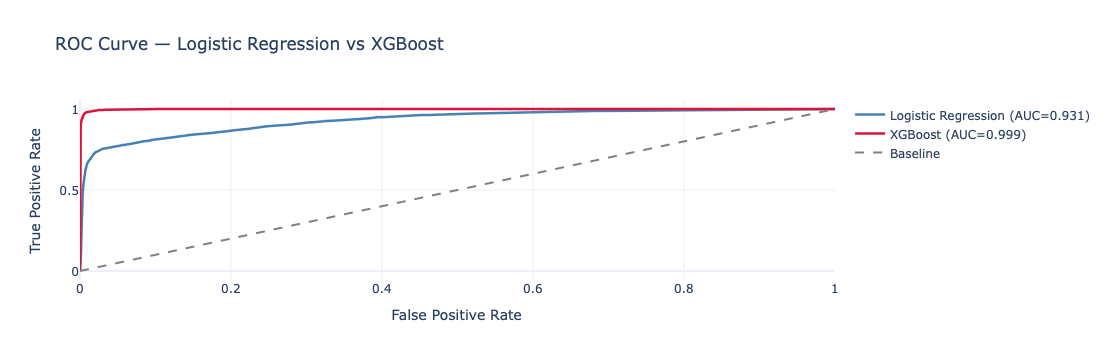

In [4]:
fig = go.Figure()
colors = ['steelblue', 'crimson']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['probs'])
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr, name=f"{name} (AUC={res['auc']:.3f})",
        mode='lines', line=dict(width=2.5, color=color)
    ))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], name='Baseline',
    mode='lines', line=dict(dash='dash', color='gray')))
fig.update_layout(
    title='ROC Curve — Logistic Regression vs XGBoost',
    xaxis_title='False Positive Rate', yaxis_title='True Positive Rate',
    template='plotly_white'
)
fig.show()

## Step 4 — Feature Importance

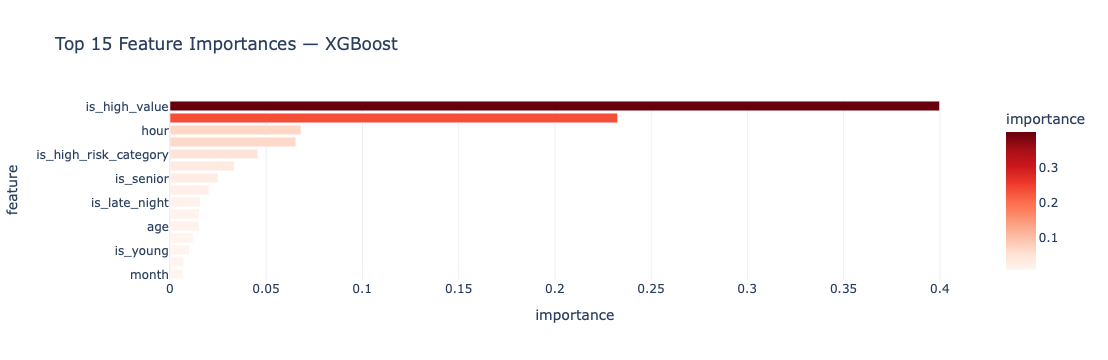

Top 5 most predictive features:
  is_high_value: 0.3998
  amt: 0.2325
  hour: 0.0680
  category_enc: 0.0654
  is_high_risk_category: 0.0457


In [5]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig = px.bar(
    importance_df, x='importance', y='feature', orientation='h',
    title='Top 15 Feature Importances — XGBoost',
    color='importance', color_continuous_scale='Reds'
)
fig.update_layout(template='plotly_white', yaxis={'categoryorder':'total ascending'})
fig.show()
print('Top 5 most predictive features:')
for _, row in importance_df.head(5).iterrows():
    print(f'  {row["feature"]}: {row["importance"]:.4f}')

## Step 5 — Top 3 High-Risk Patterns (Business Report)

In [6]:
df_test_results = X_test.copy()
df_test_results['is_fraud']   = y_test.values
df_test_results['risk_score'] = xgb_probs
df_test_results['risk_flag']  = (xgb_probs >= 0.4).astype(int)

print('=' * 60)
print('RISK SEGMENTATION REPORT — TOP 3 HIGH-RISK PATTERNS')
print('=' * 60)

# Pattern 1
late_night = df_test_results[df_test_results['is_late_night']==1]
print(f'''
🔴 PATTERN 1: Late-Night Transactions (0-5am)
   {len(late_night):,} transactions flagged
   Fraud rate: {late_night["is_fraud"].mean()*100:.1f}% vs {df_test_results["is_fraud"].mean()*100:.1f}% overall
   Recommendation: Trigger 2FA for all transactions between 0-5am
''')

# Pattern 2
high_val = df_test_results[df_test_results['amt_vs_customer_avg'] > 3]
print(f'''
🔴 PATTERN 2: Amount Spike (>3x Customer Historical Average)
   {len(high_val):,} transactions flagged
   Fraud rate: {high_val["is_fraud"].mean()*100:.1f}% vs {df_test_results["is_fraud"].mean()*100:.1f}% overall
   Recommendation: Flag transactions exceeding 3x customer average for review
''')

# Pattern 3
high_risk_cat = df_test_results[(df_test_results['is_high_risk_category']==1) & (df_test_results['is_high_value']==1)]
print(f'''
🔴 PATTERN 3: High-Value + High-Risk Category
   {len(high_risk_cat):,} transactions flagged
   Fraud rate: {high_risk_cat["is_fraud"].mean()*100:.1f}% vs {df_test_results["is_fraud"].mean()*100:.1f}% overall
   Recommendation: Add verification step for high-value shopping_net/misc_net transactions
''')

print('=' * 60)
flagged = df_test_results[df_test_results['risk_flag']==1]
print(f'Model flagged {len(flagged):,} transactions as high risk')
print(f'Precision on flagged: {(flagged["is_fraud"]==1).mean()*100:.1f}%')
print(f'XGBoost ROC-AUC:  {xgb_auc:.4f}')
print(f'LR ROC-AUC:       {lr_auc:.4f}')
print(f'Improvement:      {improvement:.1f}%')
print('\n✅ All experiments logged to MLflow')
print('Run: mlflow ui   to view experiment dashboard')

RISK SEGMENTATION REPORT — TOP 3 HIGH-RISK PATTERNS

🔴 PATTERN 1: Late-Night Transactions (0-5am)
   72,978 transactions flagged
   Fraud rate: 0.9% vs 0.5% overall
   Recommendation: Trigger 2FA for all transactions between 0-5am


🔴 PATTERN 2: Amount Spike (>3x Customer Historical Average)
   14,318 transactions flagged
   Fraud rate: 9.2% vs 0.5% overall
   Recommendation: Flag transactions exceeding 3x customer average for review


🔴 PATTERN 3: High-Value + High-Risk Category
   1,860 transactions flagged
   Fraud rate: 36.2% vs 0.5% overall
   Recommendation: Add verification step for high-value shopping_net/misc_net transactions

Model flagged 5,764 transactions as high risk
Precision on flagged: 32.9%
XGBoost ROC-AUC:  0.9992
LR ROC-AUC:       0.9309
Improvement:      7.3%

✅ All experiments logged to MLflow
Run: mlflow ui   to view experiment dashboard
